# Latent diffusion & classifier-free guidance

implementing latent diffusion model (LDM) on VAE latent space with classifier-free guidance (CFG)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## VAE definition

defining the vae architecture to compress images into latents

In [2]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)
        
        self.decoder_input = nn.Linear(latent_dim, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        z_dec = self.decoder_input(z)
        recon_x = self.decoder(z_dec)
        return recon_x, mu, logvar

In [3]:
vae = VAE(latent_dim=20).to(device)
vae_path = "vae_mnist.pth"

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

print("Training VAE from scratch...")
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
vae.train()

for epoch in range(20):
    total_loss = 0
    for x, _ in tqdm(train_loader, desc=f"VAE Epoch {epoch+1}"):
        x = x.to(device)
        optimizer.zero_grad()
        recon_x, mu, logvar = vae(x)
        
        bce = F.binary_cross_entropy(recon_x, x, reduction='sum')
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = bce + kld
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1} Loss: {total_loss / len(train_dataset):.4f}")

torch.save(vae.state_dict(), vae_path)
print(f"VAE saved to {vae_path}")

Training VAE from scratch...


VAE Epoch 1:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 Loss: 156.2534


VAE Epoch 2:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2 Loss: 118.9100


...

Epoch 18 Loss: 102.9598


VAE Epoch 19:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 19 Loss: 102.7397


VAE Epoch 20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 20 Loss: 102.5683
VAE saved to vae_mnist.pth


Checking VAE generation quality...


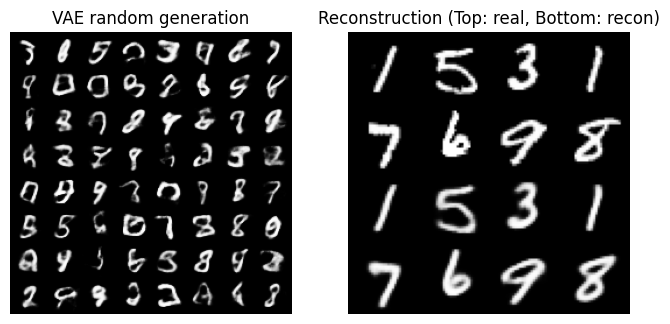

In [4]:
vae.eval()
for p in vae.parameters():
    p.requires_grad = False

print("Checking VAE generation quality...")
with torch.no_grad():
    z_sample = torch.randn(64, 20).to(device)
    gen_imgs = vae.decoder(vae.decoder_input(z_sample)).cpu()

    x_real = next(iter(train_loader))[0][:8].to(device)
    recon_real, _, _ = vae(x_real)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("VAE random generation")
plt.imshow(make_grid(gen_imgs, nrow=8).permute(1, 2, 0))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Reconstruction (Top: real, Bottom: recon)")
plt.imshow(make_grid(torch.cat([x_real.cpu(), recon_real.cpu()], dim=0), nrow=4).permute(1, 2, 0))
plt.axis('off')
plt.show()

## Latent extraction

running the pre-trained vae on mnist to get latent vectors

In [5]:
latents = []
labels = []

print("Extracting latents...")
with torch.no_grad():
    for x, y in tqdm(train_loader):
        x = x.to(device)
        mu, logvar = vae.encode(x)
        z = vae.reparameterize(mu, logvar)
        latents.append(z.cpu())
        labels.append(y)

latents = torch.cat(latents, dim=0)
labels = torch.cat(labels, dim=0)

print(f"Latents shape: {latents.shape}")
print(f"Mean: {latents.mean():.4f}, Std: {latents.std():.4f}")

latent_dataset = TensorDataset(latents, labels)
latent_loader = DataLoader(latent_dataset, batch_size=128, shuffle=True)

Extracting latents...


  0%|          | 0/469 [00:00<?, ?it/s]

Latents shape: torch.Size([60000, 20])
Mean: 0.0031, Std: 0.9967


## Diffusion model (MLP)

using a simple mlp instead of a u-net since inputs are 1d vectors

In [6]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.SiLU(),
        )

    def forward(self, x):
        return x + self.block(x)


class LatentDiffusionMLP(nn.Module):
    def __init__(self, latent_dim=20, hidden_dim=256, time_dim=64, num_classes=10, dropout=0.1):
        super().__init__()
        
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, hidden_dim),
            nn.SiLU()
        )
        
        self.class_emb = nn.Embedding(num_classes + 1, hidden_dim)
        self.input_proj = nn.Linear(latent_dim, hidden_dim)
        
        self.blocks = nn.Sequential(
            ResBlock(hidden_dim, dropout),
            ResBlock(hidden_dim, dropout),
            ResBlock(hidden_dim, dropout),
            ResBlock(hidden_dim, dropout)
        )
        
        self.output_proj = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x, t, labels):
        t_emb = self.time_mlp(t)
        c_emb = self.class_emb(labels)
        
        h = self.input_proj(x)
        h = h + t_emb + c_emb
        h = self.blocks(h)
        
        return self.output_proj(h)

## Training

training the model to predict noise added to latents

In [7]:
class DDPMScheduler:
    def __init__(self, n_timesteps=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.n_timesteps = n_timesteps
        self.betas = torch.linspace(beta_start, beta_end, n_timesteps).to(device)
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)
        self.device = device

    def add_noise(self, x_0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_0)
        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t][:, None]
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t][:, None]
        return sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise, noise


n_timesteps = 1000
lr = 1e-3
n_epochs = 20
p_uncond = 0.1
null_class = 10

model = LatentDiffusionMLP(latent_dim=20, num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = DDPMScheduler(n_timesteps=n_timesteps, device=device)
criterion = nn.MSELoss()

print("Starting latent diffusion training...")
for epoch in range(n_epochs):
    model.train()
    pbar = tqdm(latent_loader, desc=f"Epoch {epoch+1}/{n_epochs}")
    loss_epoch = 0
    
    for z, labels in pbar:
        z = z.to(device)
        labels = labels.to(device)
        batch_size = z.shape[0]
        
        t = torch.randint(0, n_timesteps, (batch_size,), device=device).long()
        noisy_z, noise = scheduler.add_noise(z, t)
        
        mask = torch.rand(batch_size, device=device) < p_uncond
        labels[mask] = null_class
        
        noise_pred = model(noisy_z, t, labels)
        loss = criterion(noise_pred, noise)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        loss_epoch += loss.item()
        pbar.set_postfix(loss=loss.item())
    
    print(f"Avg Loss: {loss_epoch / len(latent_loader):.4f}")

Starting latent diffusion training...


Epoch 1/20:   0%|          | 0/469 [00:00<?, ?it/s]

Avg Loss: 0.3035


Epoch 2/20:   0%|          | 0/469 [00:00<?, ?it/s]

Avg Loss: 0.2575


...

Avg Loss: 0.2384


Epoch 19/20:   0%|          | 0/469 [00:00<?, ?it/s]

Avg Loss: 0.2378


Epoch 20/20:   0%|          | 0/469 [00:00<?, ?it/s]

Avg Loss: 0.2374


## Sampling

generating new digits by denoising random noise

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

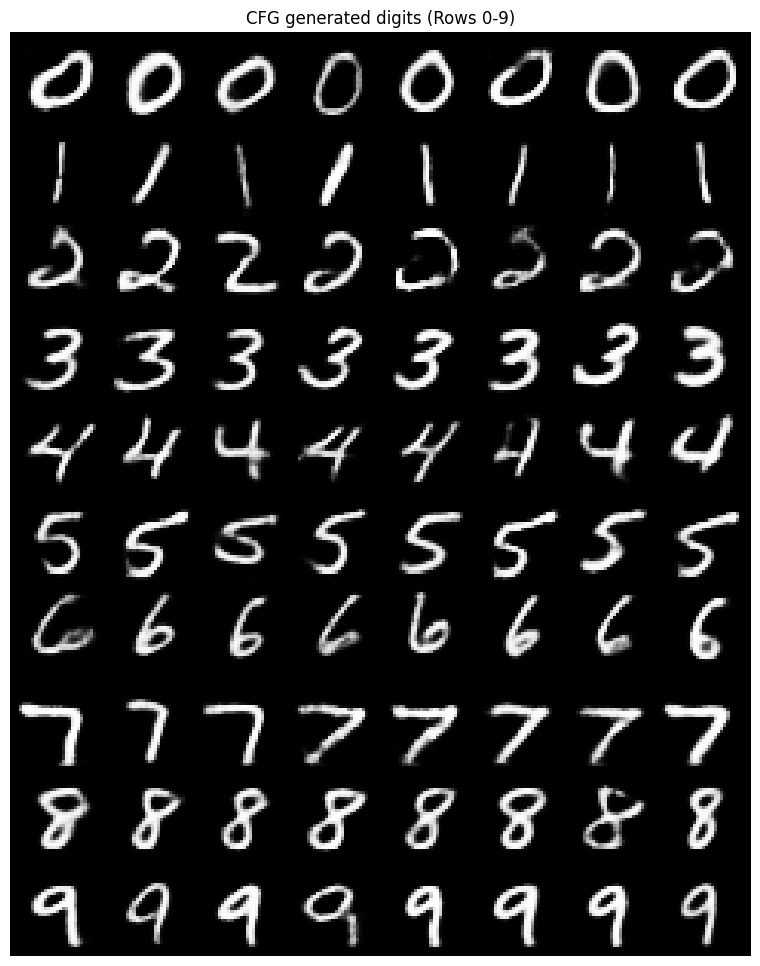

In [8]:
def sample_cfg(model, scheduler, n_samples=10, latent_dim=20, guidance_scale=3.0, class_label=None):
    model.eval()
    with torch.no_grad():
        z = torch.randn((n_samples, latent_dim)).to(device)
        
        if class_label is not None:
            labels = torch.full((n_samples,), class_label, dtype=torch.long, device=device)
        else:
            labels = torch.randint(0, 10, (n_samples,), device=device)
            
        null_labels = torch.full((n_samples,), 10, dtype=torch.long, device=device)
        
        for i in tqdm(reversed(range(scheduler.n_timesteps)), desc='Sampling', total=scheduler.n_timesteps):
            t = torch.full((n_samples,), i, dtype=torch.long, device=device)
            
            z_in = torch.cat([z, z], dim=0)
            t_in = torch.cat([t, t], dim=0)
            c_in = torch.cat([labels, null_labels], dim=0)
            
            noise_pred_all = model(z_in, t_in, c_in)
            noise_pred_cond, noise_pred_uncond = noise_pred_all.chunk(2, dim=0)
            
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)
            
            alpha = scheduler.alphas[i]
            alpha_cumprod = scheduler.alphas_cumprod[i]
            beta = scheduler.betas[i]
            
            if i > 0:
                noise = torch.randn_like(z)
            else:
                noise = torch.zeros_like(z)
            
            z = (1 / torch.sqrt(alpha)) * (z - ((1 - alpha) / (torch.sqrt(1 - alpha_cumprod))) * noise_pred) + torch.sqrt(beta) * noise
            
        return z

generated_latents = []
for digit in range(10):
    z = sample_cfg(model, scheduler, n_samples=8, guidance_scale=4.0, class_label=digit)
    generated_latents.append(z)

generated_latents = torch.cat(generated_latents, dim=0)

with torch.no_grad():
    z_dec = vae.decoder_input(generated_latents)
    images = vae.decoder(z_dec).cpu()

plt.figure(figsize=(10, 12))
plt.axis("off")
plt.title("CFG generated digits (Rows 0-9)")
plt.imshow(make_grid(images, nrow=8).permute(1, 2, 0))
plt.show()

## CFG scale analysis

checking how different guidance scales affect the results

Generating scale variations...


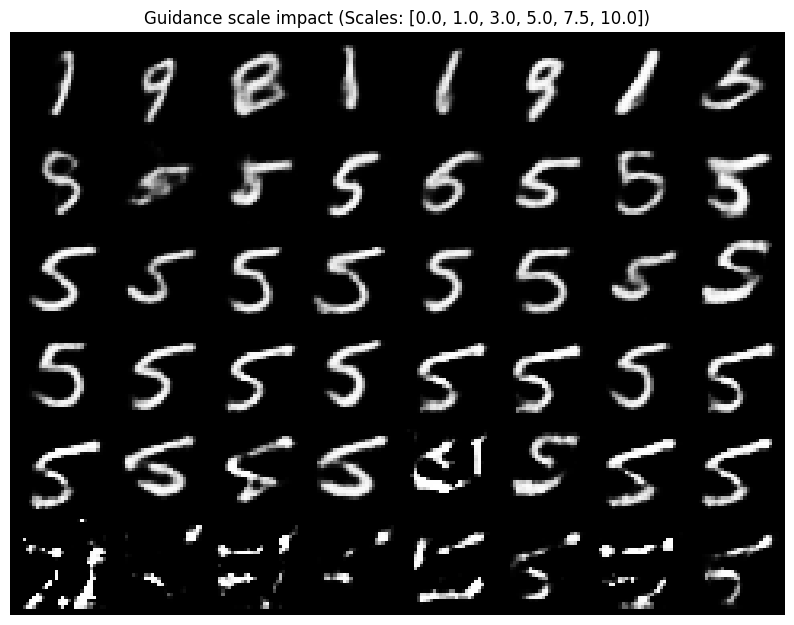

In [9]:
scales = [0.0, 1.0, 3.0, 5.0, 7.5, 10.0]
digit_target = 5
n_per_scale = 8

scale_samples = []

fixed_noise = torch.randn((n_per_scale, 20)).to(device)


def sample_with_fixed_noise(model, scheduler, z_start, scale, label):
    model.eval()
    with torch.no_grad():
        z = z_start.clone()
        labels = torch.full((z.shape[0],), label, dtype=torch.long, device=device)
        null_labels = torch.full((z.shape[0],), 10, dtype=torch.long, device=device)
        
        for i in reversed(range(scheduler.n_timesteps)):
            t = torch.full((z.shape[0],), i, dtype=torch.long, device=device)
            
            z_in = torch.cat([z, z], dim=0)
            t_in = torch.cat([t, t], dim=0)
            c_in = torch.cat([labels, null_labels], dim=0)
            
            noise_pred_all = model(z_in, t_in, c_in)
            noise_pred_cond, noise_pred_uncond = noise_pred_all.chunk(2, dim=0)
            
            noise_pred = noise_pred_uncond + scale * (noise_pred_cond - noise_pred_uncond)
            
            alpha = scheduler.alphas[i]
            alpha_cumprod = scheduler.alphas_cumprod[i]
            beta = scheduler.betas[i]
            
            if i > 0:
                noise = torch.randn_like(z)
            else:
                noise = torch.zeros_like(z)
            
            z = (1 / torch.sqrt(alpha)) * (z - ((1 - alpha) / (torch.sqrt(1 - alpha_cumprod))) * noise_pred) + torch.sqrt(beta) * noise
            
        return z


print("Generating scale variations...")

for s in scales:
    z_out = sample_with_fixed_noise(model, scheduler, fixed_noise, s, digit_target)
    scale_samples.append(z_out)

scale_samples = torch.cat(scale_samples, dim=0)

with torch.no_grad():
    z_dec = vae.decoder_input(scale_samples)
    images_scale = vae.decoder(z_dec).cpu()

plt.figure(figsize=(10, 8))
plt.axis("off")
plt.title(f"Guidance scale impact (Scales: {scales})")
plt.imshow(make_grid(images_scale, nrow=n_per_scale).permute(1, 2, 0))
plt.show()